In [1]:
from langchain_openai import ChatOpenAI 
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

load_dotenv()

True

In [2]:
model = ChatOpenAI()

In [3]:
# Create the state 
class LLMState(TypedDict):
    question: str
    answer: str

In [4]:
# function llm_qa
def llm_qa(state: LLMState) -> LLMState:
    # Extract the question from the state
    question = state["question"]
    
    # form a prompt 
    prompt = f"Answer the question: {question}"
    
    # ask that question to the LLM
    answer = model.invoke(prompt).content
    
    # update the answer in the state
    state["answer"] = answer
    
    return state

In [5]:
# Create a graph
graph = StateGraph(LLMState) 

# Add Nodes
graph.add_node("LLm_qa", llm_qa)

# add Edges
graph.add_edge(START, "LLm_qa")
graph.add_edge("LLm_qa", END)

# compile the graph
workflow = graph.compile()

In [6]:
# Execute the graph
initial_state = {"question": "What is LangGraph?"}
final_state = workflow.invoke(initial_state)

# Print the final state
print(final_state)

{'question': 'What is LangGraph?', 'answer': 'LangGraph is a tool for creating and analyzing language networks. It allows users to visualize and study the relationships between words, concepts, or other linguistic elements in a graphical form. By mapping out these connections, LangGraph can help researchers better understand linguistic structures and patterns.'}


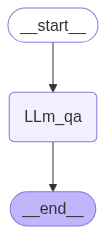

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())